In [7]:
import yfinance as yf
import pandas as pd

gold = yf.download("GC=F", start="2015-01-01", end="2025-12-31")

gold.head()

gold.to_csv("gold_price_2025.csv")






/tmp/ipykernel_338/2476493590.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  gold = yf.download("GC=F", start="2015-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed


In [8]:
dxy = yf.download("DX-Y.NYB", start="2015-01-01", end="2025-12-31", auto_adjust=True)

dxy.head()

dxy.to_csv("dxy_index_2025.csv")

[*********************100%***********************]  1 of 1 completed


In [9]:
import pandas as pd

df = pd.DataFrame()

df["Gold"] = gold["Close"]
df["DXY"] = dxy["Close"]

df = df.dropna()

df.head()

df.to_csv("gold_dxy_2025.csv")




In [10]:
correlation = df["Gold"].corr(df["DXY"])

print("Correlation:", round(correlation, 2))

Correlation: 0.34


### Interpretation of Correlation Result

The correlation between Gold Price and the U.S. Dollar Index is 0.34, indicating a weak positive relationship during the period 2015–2025.

Although economic theory often suggests a negative relationship between the dollar and gold, the empirical results show a positive correlation. This may occur due to several global macroeconomic factors such as:

- Global inflation
- Economic crises
- Safe haven demand
- Changes in interest rate policies

During periods of uncertainty, both the dollar and gold may rise simultaneously as investors seek safe assets.

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

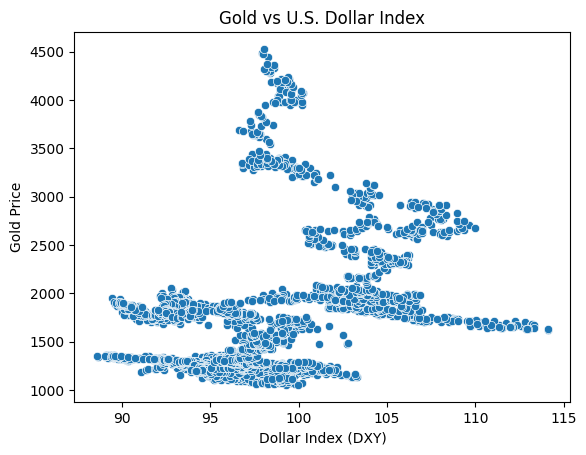

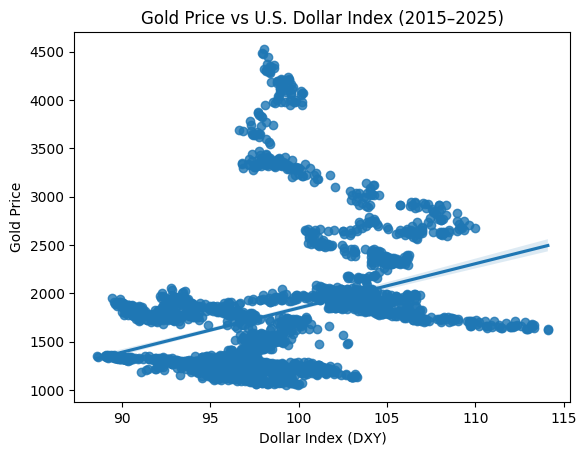

In [13]:
sns.scatterplot(x=df["DXY"], y=df["Gold"])
plt.title("Gold vs U.S. Dollar Index")
plt.xlabel("Dollar Index (DXY)")
plt.ylabel("Gold Price")
plt.show()

sns.regplot(x=df["DXY"], y=df["Gold"])

plt.title("Gold Price vs U.S. Dollar Index (2015–2025)")
plt.xlabel("Dollar Index (DXY)")
plt.ylabel("Gold Price")

plt.show()

### Visualization Insight

The scatter plot shows a weak positive relationship between the U.S. Dollar Index and gold prices during the 2015–2025 period.

Although traditional theory often suggests an inverse relationship, the data indicates that both assets sometimes move in the same direction, possibly due to global economic uncertainty and safe-haven demand.

In [14]:
import statsmodels.api as sm

In [16]:
X = df["DXY"]
y = df["Gold"]

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   Gold   R-squared:                       0.113
Model:                            OLS   Adj. R-squared:                  0.113
Method:                 Least Squares   F-statistic:                     352.1
Date:                Sun, 08 Mar 2026   Prob (F-statistic):           5.02e-74
Time:                        07:30:53   Log-Likelihood:                -21707.
No. Observations:                2763   AIC:                         4.342e+04
Df Residuals:                    2761   BIC:                         4.343e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const      -2737.1585    240.507    -11.381      0.0

### Regression Analysis Interpretation

The regression results indicate a statistically significant positive relationship between the U.S. Dollar Index (DXY) and gold prices during the 2015–2025 period.

The coefficient of approximately 45.84 suggests that a one-point increase in the Dollar Index is associated with an increase of about 45.8 units in gold prices within the model.

However, the R-squared value of 0.113 indicates that the Dollar Index explains only around 11.3% of the variation in gold prices, suggesting that other macroeconomic variables also play important roles.

In [17]:
df.to_csv("gold_dxy_analysis.csv", index=False)

In [18]:
corr_matrix = df[["Gold","DXY"]].corr()

print(corr_matrix)

          Gold       DXY
Gold  1.000000  0.336289
DXY   0.336289  1.000000


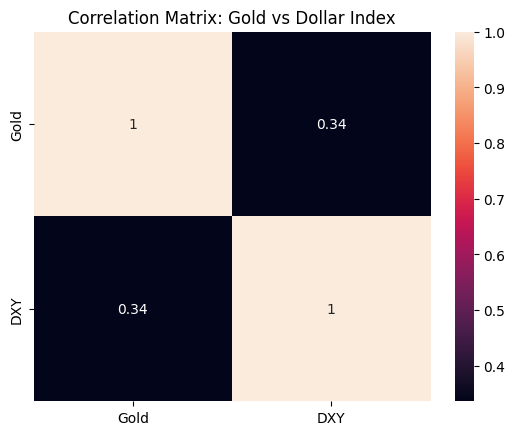

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df[["Gold","DXY"]].corr()

sns.heatmap(corr_matrix, annot=True)

plt.title("Correlation Matrix: Gold vs Dollar Index")
plt.show()

### Correlation Heatmap

The heatmap visualizes the correlation matrix between gold prices and the U.S. Dollar Index.

The correlation value of approximately 0.34 indicates a weak positive relationship between the two variables during the 2015–2025 period.